<center><h1> EN3160 - Image Processing and Machine Vision </h1></center>

## Assignment 1: Intensity Transformations and Neighborhood Filtering

**Student Name:** Nuwanaka WAS <br>
**Index Number:** 230449N <br>
**GitHub Profile:** [https://github.com/samirunuwanaka](https://github.com/samirunuwanaka)  <br>
**Repo Link:** [https://github.com/samirunuwanaka/ComputerVision/blob/main/Assignment/230449N.ipynb](https://github.com/samirunuwanaka/ComputerVision/blob/main/Assignment/230449N.ipynb)

---  
### Instructions & Guidelines
1. Complete the implementation stubs provided in each section below.
2. Ensure all plots, transformed images, and comparative histograms are rendered directly within this notebook.
3. Fill in the discussion and analysis sections for each problem.
4. Commit your work regularly to GitHub throughout the project lifecycle.
5. **Submission Requirements:** Export this notebook directly to PDF (`230449N_a01.pdf`). Do not copy-paste screenshots into external word processors. Maximum page limit: **10 pages**.

--- 
## Setup and Dependencies

In [27]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os

# Path configurations
IMAGE_DIR = 'images/images'

# Helper function for image display
def show_image(img, title='Image', cmap=None):
    plt.figure(figsize=(6, 6))
    if len(img.shape) == 3 and cmap is None:
        plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap=cmap if cmap else 'gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

print("OpenCV Version:", cv.__version__)

OpenCV Version: 5.0.0


--- 
## Question 1: Piecewise Linear Intensity Transformation

### Task Description
Implement a piecewise linear intensity transformation function `intensity_transform(im, breakpoints)` where `breakpoints` defines a mapping from input intensities $x$ to output intensities $y$, e.g.,
$$
\text{breakpoints} = \begin{bmatrix}
0 & 0 \\
50 & 50 \\
100 & 150 \\
150 & 255 \\
255 & 255
\end{bmatrix}
$$

### Requirements:
1. Implement `intensity_transform(im, breakpoints)` using lookup tables (LUT) or piecewise interpolation (`np.interp`).
2. Load target image `im01.png` (or `im01small.png`).
3. Experiment with different break points to achieve a visually pleasing contrast enhancement.
4. Display the transformation curve plot alongside the original and transformed images side-by-side.

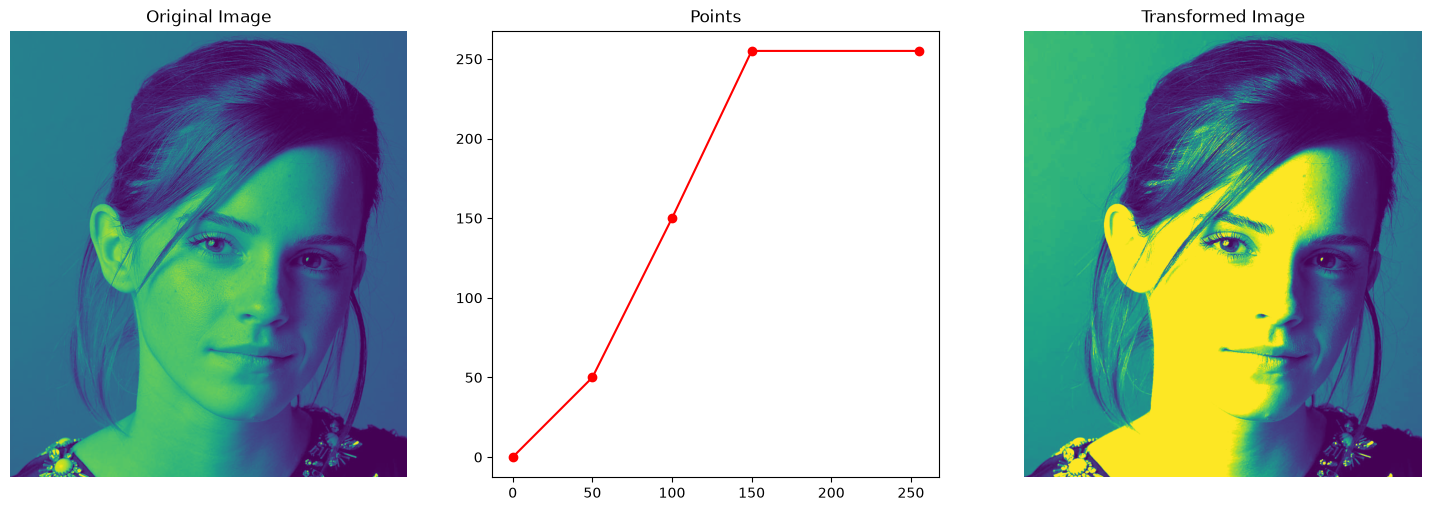

In [28]:
def intensity_transform(im: np.ndarray, breakpoints: np.ndarray) -> np.ndarray:
    """
    Applies piecewise linear intensity transformation to an input image.
    
    Parameters:
        im (np.ndarray): Input image (grayscale or color)
        breakpoints (np.ndarray): Nx2 matrix of [input_intensity, output_intensity]
        
    Returns:
        np.ndarray: Transformed image of same shape and uint8 dtype
    """
    return np.interp(im, breakpoints[:, 0], breakpoints[:, 1]).astype(np.uint8)

# --- Test & Visualization Template ---
im1 = cv.imread(os.path.join(IMAGE_DIR, 'q1.jpeg'), cv.IMREAD_GRAYSCALE)
pts = np.array([[0,   0],
                [50,  50],
                [100, 150],
                [150, 255],
                [255, 255]])
im1_trans = intensity_transform(im1, pts)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# Original
ax[0].imshow(im1)
ax[0].set_title('Original Image')
ax[0].axis('off')

# Points
ax[1].plot(pts[:, 0], pts[:, 1], 'ro-')
ax[1].set_title('Points')
ax[1].set_aspect('equal')

# Transformed
ax[2].imshow(im1_trans)
ax[2].set_title('Transformed Image')
ax[2].axis('off')

plt.tight_layout()
plt.show()


### Discussion & Observations (Question 1)
The output of the transformed image must be with less shadows but here it is not visible so good. But as per the some portion of high contrast has been set to constant some picture parts have gone showing bright light and after 50 the internsity is boosted so the overall contrast of the picture has increased.

--- 
## Question 2: Tissue Accentuation in Brain Proton Density Image

### Task Description
Apply piecewise linear intensity transformations on the brain proton density slice (`im02.png` / `im02small.png`) to selectively accentuate:
- **(a)** White matter
- **(b)** Gray matter

### Requirements:
1. Analyze histogram of the brain proton density slice to identify intensity ranges corresponding to white matter and gray matter.
2. Design custom breakpoint curves for (a) White Matter accentuation and (b) Gray Matter accentuation.
3. Plot transformation curves and display the original vs accentuated images.

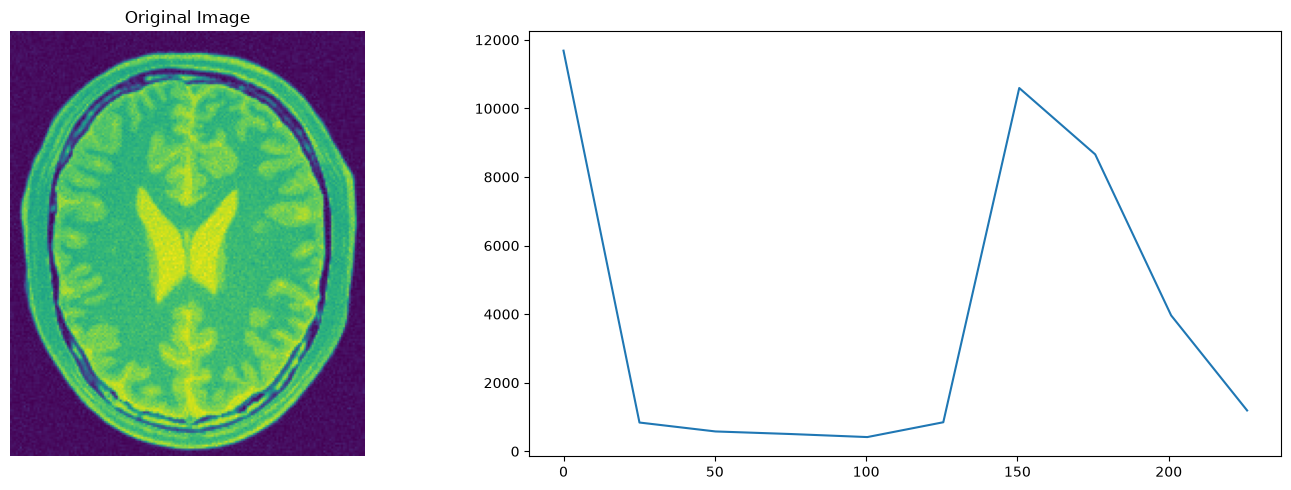

breakpoints of intensity transfer function are [0 0] [ 25 100] [125 100] [255 255]


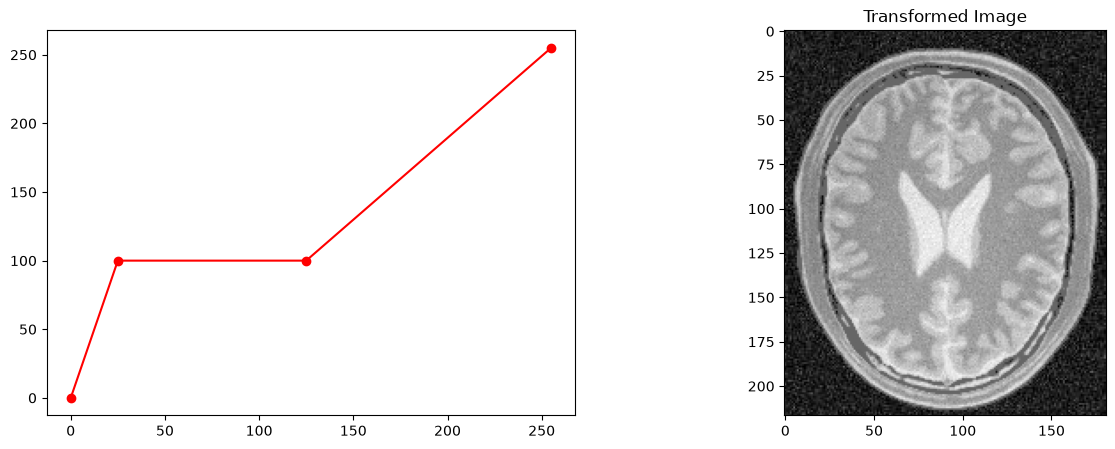

In [29]:
im2 = cv.imread(os.path.join(IMAGE_DIR,'q2.jpeg'), cv.IMREAD_GRAYSCALE)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Original
ax[0].imshow(im2)
ax[0].set_title('Original Image')
ax[0].axis('off')

# Points
hist = np.histogram(im2.flatten())
ax[1].plot(hist[1][:-1], hist[0])

plt.tight_layout()
plt.show()

pts = np.array([
    [0,     0],
    [25,    100],
    [125,   100],
    [255,   255]
])
print("breakpoints of intensity transfer function are",*pts)

# Transformed
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].plot(pts[:,0],pts[:,1],'ro-')
ax[1].imshow(intensity_transform(im2, pts), cmap='gray')
ax[1].set_title('Transformed Image')
plt.show()

# cdf = hist.cumsum()

# # Ignore zero values in the CDF
# cdf_min = cdf[cdf > 0][0]

# # Histogram equalization mapping
# mapping = ((cdf - cdf_min) / (im2.size - cdf_min) * 255).clip(0, 255).astype(np.uint8)

# plt.plot(range(256), mapping)
# plt.xlabel('Original intensity')
# plt.ylabel('Equalized intensity')
# plt.title('Histogram Equalization Transformation')
# plt.grid()
# plt.show()

### Discussion & Observations (Question 2)
When looking at the histogram there is a intensity range where any of the intensity levels are not present so in this case we can increase the intensity range of grey matter and white matter to that range effectively increasing the intensity resolution and get more distinguish change between two intensities

--- 
## Question 3: Gamma Correction in L*a*b* Color Space

### Task Description
Consider the image shown in Fig. 3 (`im03.png` / `im03small.png`).
- **(a)** Convert image to $L^*a^*b^*$ color space and apply gamma correction to the $L^*$ plane. State chosen $\gamma$ value.
- **(b)** Display original vs gamma-corrected image, along with histograms of the $L^*$ plane before and after correction.

### Formula:
$$L_{\text{out}} = 255 \times \left(\frac{L_{\text{in}}}{255}\right)^\gamma$$

<pre style="display:inline-block; text-align:left; font-size:16px;">

                       +b*
                    Yellow
                       ↑
                       │
                       │
       −a* Green  ←───●───→  +a* Red
                       │
                       │
                       ↓
                      −b*
                     Blue

</pre>

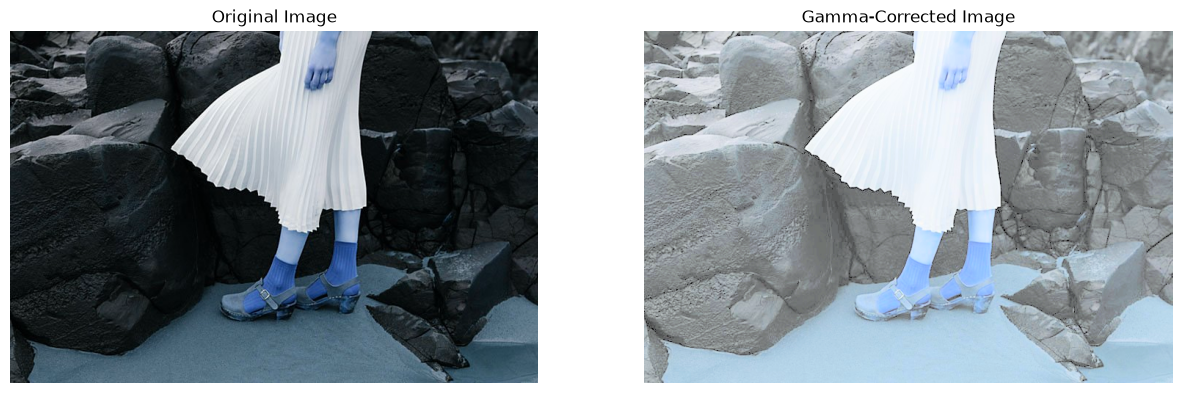

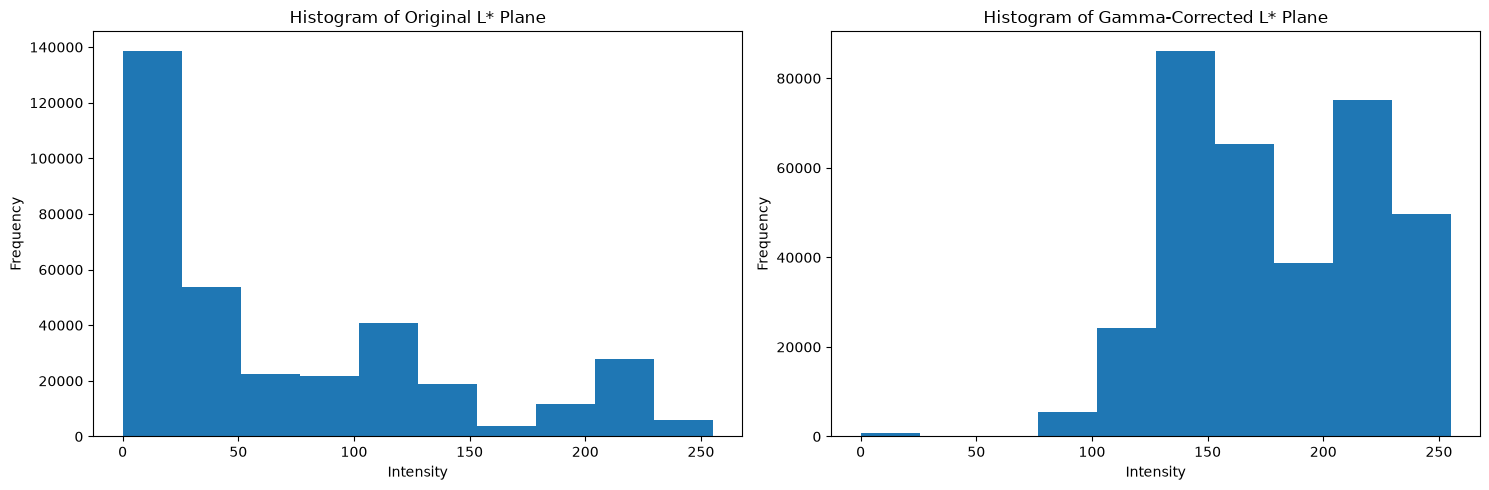

In [30]:
def gamma_correct_L_plane(im_bgr: np.ndarray, gamma: float) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Applies gamma correction to the L* plane in L*a*b* color space.
    
    Parameters:
        im_bgr (np.ndarray): BGR image
        gamma (float): Gamma exponent
        
    Returns:
        tuple: (corrected_bgr_image, L_orig, L_corrected)
    """
    imLAB = cv.cvtColor(im_bgr, cv.COLOR_BGR2LAB)
    L_in = np.array(imLAB[:, :, 0], dtype=np.uint8)
    L_out = 255 * ((L_in / 255) ** gamma)
    imLAB[:, :, 0] = L_out
    return cv.cvtColor(imLAB, cv.COLOR_LAB2BGR), L_in, L_out

# --- Template Execution ---
im3 = cv.imread(os.path.join(IMAGE_DIR, 'WhatsApp Image 2026-09-09 at 20.02.44 (1).jpeg'))
gamma_val = 0.2  # Choose optimal gamma
im3_corrected, L_orig, L_corr = gamma_correct_L_plane(im3, gamma_val)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].imshow(im3)
ax[0].set_title('Original Image')
ax[0].axis('off')
ax[1].imshow(im3_corrected)
ax[1].set_title('Gamma-Corrected Image')
ax[1].axis('off')
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].hist(L_orig.flatten())
ax[0].set_title('Histogram of Original L* Plane')
ax[0].set_xlabel('Intensity')
ax[0].set_ylabel('Frequency')
ax[1].hist(L_corr.flatten())
ax[1].set_title('Histogram of Gamma-Corrected L* Plane')
ax[1].set_xlabel('Intensity')
ax[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

### Discussion & Observations (Question 3)
In $La^*b^*$ the gamma correcion was added to all RGB values. So, its easy to use $La^*b^*$ instead of using gamma correction for each RGB value

--- 
## Question 4: Vibrance Enhancement in HSV Color Space

### Task Description
Enhance photograph vibrance on image `im04.jpg` (`im04small.jpg`) by applying the intensity transformation function:
$$f(x) = \min\left(x + a \times 128 e^{-\frac{(x-128)^2}{2\sigma^2}}, 255\right)$$
to the Saturation ($S$) plane in HSV color space, where $x \in [0, 255]$, $a \in [0, 1]$, and $\sigma = 70$.

### Requirements:
1. **(a)** Split `im04.jpg` into Hue ($H$), Saturation ($S$), and Value ($V$) planes.
2. **(b)** Apply the vibrance transform formula to the $S$ plane.
3. **(c)** Adjust $a$ for optimal visual results and report chosen $a$.
4. **(d)** Recombine $H, S_{\text{enhanced}}, V$ back into BGR image.
5. **(e)** Display original image, vibrance-enhanced image, and transformation plot $f(x)$ vs $x$.

D:\Temp\ipykernel_20228\1495923243.py:7: RuntimeWarning: overflow encountered in scalar subtract
  x + a * 128 * np.exp(-((x - 128)**2) / (2 * sigma**2)),
D:\Temp\ipykernel_20228\1495923243.py:7: RuntimeWarning: overflow encountered in scalar negative
  x + a * 128 * np.exp(-((x - 128)**2) / (2 * sigma**2)),


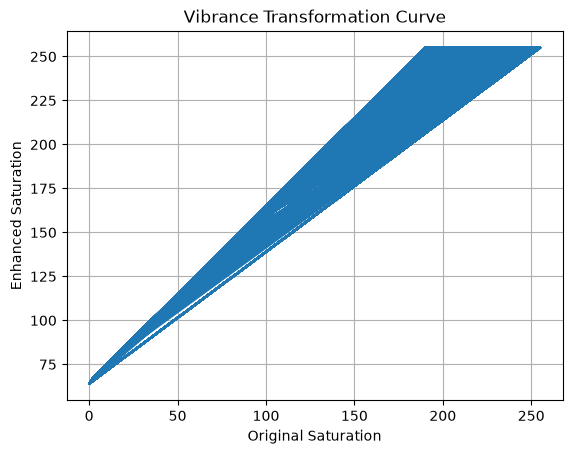

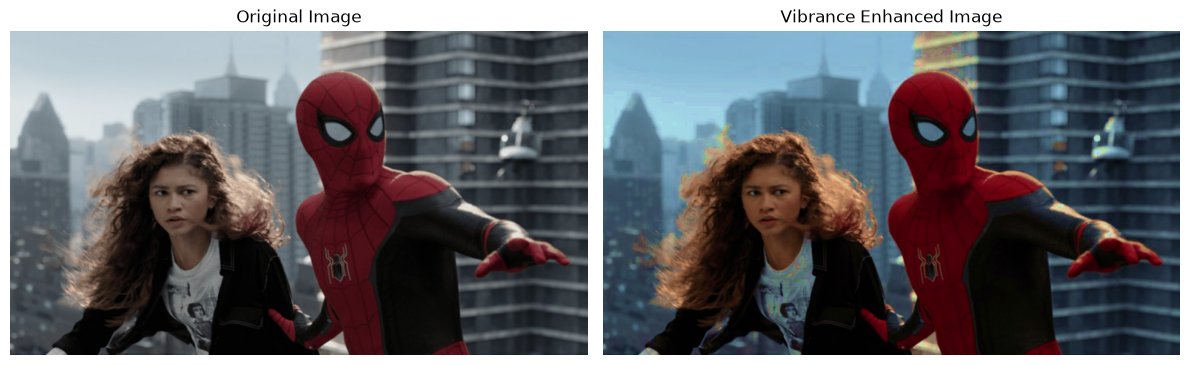

In [31]:
def vibrance_transform(S_plane: np.ndarray, a: float, sigma: float = 70.0) -> np.ndarray:
    """
    Applies vibrance enhancement function to Saturation channel.
    """
    return np.array([
        np.uint8(min(
            x + a * 128 * np.exp(-((x - 128)**2) / (2 * sigma**2)),
            255
        ))
        for x in S_plane.flatten()
    ]).reshape(S_plane.shape)
    pass

# --- Template Execution ---
im4 = cv.imread(os.path.join(IMAGE_DIR, 'WhatsApp Image 2026-09-09 at 20.02.441.jpeg'))
hsv = cv.cvtColor(im4, cv.COLOR_BGR2HSV)
H, S, V = cv.split(hsv)
a_val = 0.5  # Tune value
S_enh = vibrance_transform(S, a=a_val)
hsv_enh = cv.merge([H, S_enh, V])
im4_enh = cv.cvtColor(hsv_enh, cv.COLOR_HSV2BGR)

plt.plot(S.flatten(), S_enh.flatten())
plt.title('Vibrance Transformation Curve')
plt.xlabel('Original Saturation')
plt.ylabel('Enhanced Saturation')
plt.grid()
plt.show()

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(im4, cv.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(im4_enh, cv.COLOR_BGR2RGB))
plt.title('Vibrance Enhanced Image')
plt.axis('off')
plt.tight_layout()
plt.show()

### Discussion & Observations (Question 4)
The Gaussian weighting makes the enhancement strongest around the middle of the saturation range and gradually reduces it toward the extreme values. Therefore, highly saturated colours near the upper end of the range receive less additional amplification than they would with a uniform saturation increase. This reduces the likelihood of values exceeding the valid 8-bit range ([0,255]), thereby helping to avoid clipping and loss of detail in vibrant colours.

--- 
## Question 5: Custom Histogram Equalization

### Task Description
Write a custom function from scratch to carry out histogram equalization on `im05.jpg`.

### Requirements:
1. Implement `custom_histogram_equalization(img_gray)` without using OpenCV's `cv.equalizeHist`.
2. Compute intensity frequency histogram $h(r_k)$.
3. Calculate Probability Density Function (PDF) $p(r_k) = h(r_k) / M N$.
4. Compute Cumulative Distribution Function (CDF) $T(r_k) = \sum p(r_k)$.
5. Map intensity levels $s_k = \text{round}(255 \cdot T(r_k))$.
6. Display image before and after equalization alongside their histograms.

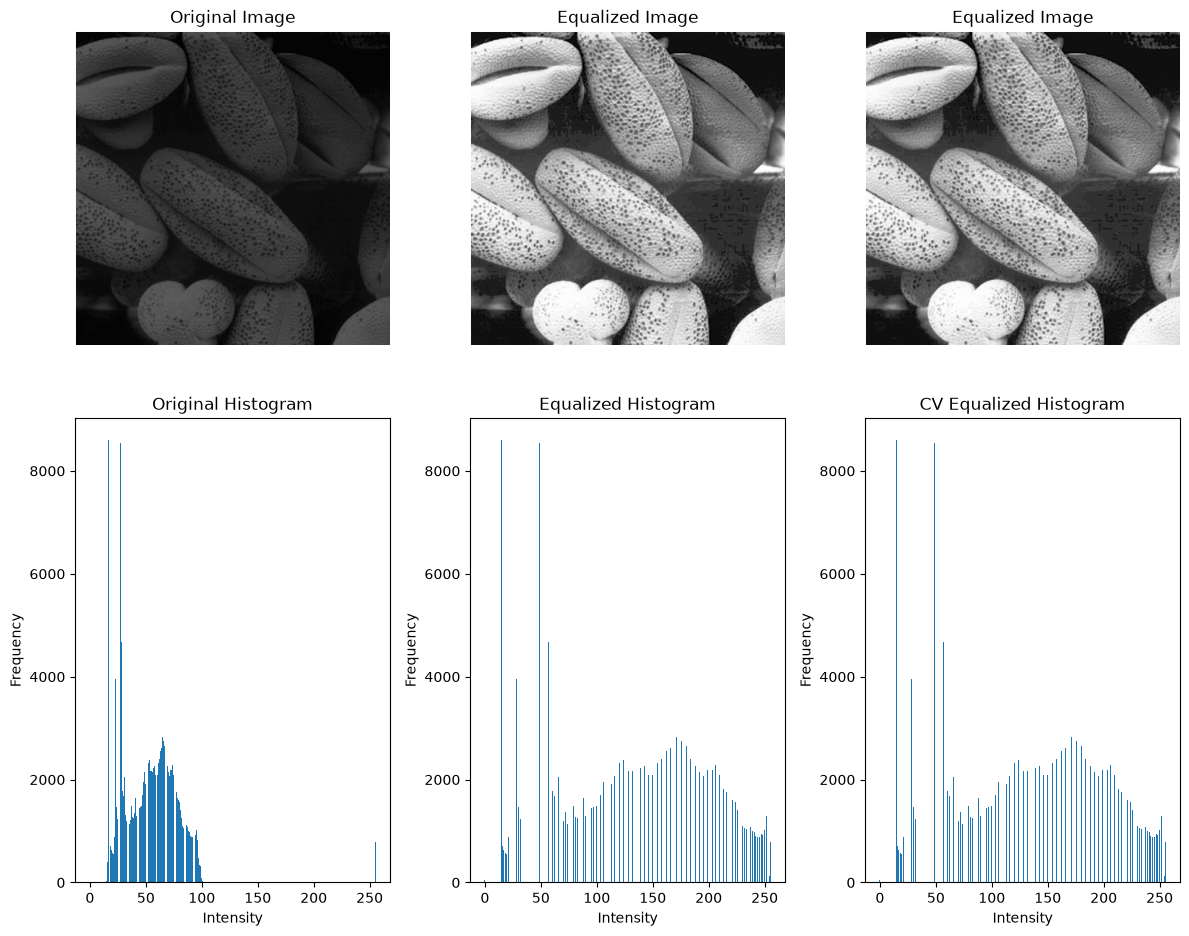

In [32]:
def custom_histogram_equalization(img_gray: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Computes histogram equalization manually.
    
    Returns:
        tuple: (equalized_image, orig_hist, eq_hist)
    """

    # --------------------------------------------------
    # 1. Calculate histogram
    # --------------------------------------------------
    intensity_frequency = np.array(
        [[i, np.count_nonzero(img_gray == i)] for i in range(256)]
    )

    # Original histogram
    orig_hist = intensity_frequency[:, 1].copy()

    # --------------------------------------------------
    # 2. Convert frequency to probability
    # --------------------------------------------------
    probability = intensity_frequency[:, 1] / np.sum(intensity_frequency[:, 1])

    # --------------------------------------------------
    # 3. Calculate CDF
    # --------------------------------------------------
    cdf = np.cumsum(probability)

    # --------------------------------------------------
    # 4. Scale CDF to [0, 255]
    # --------------------------------------------------
    mapping = np.round(255 * cdf).astype(np.uint8)

    # --------------------------------------------------
    # 5. Map original image intensities to new intensities
    # --------------------------------------------------
    equalized_image = mapping[img_gray]

    # --------------------------------------------------
    # 6. Calculate equalized histogram
    # --------------------------------------------------
    eq_hist = np.bincount(
        equalized_image.ravel(),
        minlength=256
    )

    return equalized_image, orig_hist, eq_hist
    pass

# --- Template Execution ---
im5 = cv.imread(os.path.join(IMAGE_DIR, 'image.png'), cv.IMREAD_GRAYSCALE)
im5_eq, hist_orig, hist_eq = custom_histogram_equalization(im5)

im5_eq_cv = cv.equalizeHist(im5)
im5_eq_cv_hist = np.array(
        [[i, np.count_nonzero(im5_eq_cv == i)] for i in range(256)]
    )

fig, ax = plt.subplots(2, 3, figsize=(12, 10))
# Original Image
ax[0, 0].imshow(im5, cmap='gray')
ax[0, 0].set_title('Original Image')
ax[0, 0].axis('off')

# Original Histogram
ax[1, 0].bar(range(256), hist_orig)
ax[1, 0].set_title('Original Histogram')
ax[1, 0].set_xlabel('Intensity')
ax[1, 0].set_ylabel('Frequency')

# Equalized Image
ax[0, 1].imshow(im5_eq, cmap='gray')
ax[0, 1].set_title('Equalized Image')
ax[0, 1].axis('off')

# Equalized Histogram
ax[1, 1].bar(range(256), hist_eq)
ax[1, 1].set_title('Equalized Histogram')
ax[1, 1].set_xlabel('Intensity')
ax[1, 1].set_ylabel('Frequency')

# Equalized Image
ax[0, 2].imshow(im5_eq_cv, cmap='gray')
ax[0, 2].set_title('Equalized Image')
ax[0, 2].axis('off')

# Equalized Histogram
ax[1, 2].bar(range(256), im5_eq_cv_hist[:, 1])
ax[1, 2].set_title('CV Equalized Histogram')
ax[1, 2].set_xlabel('Intensity')
ax[1, 2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Discussion & Observations (Question 5)
Both of manually calculated and opencv calculated histograms are equal

--- 
## Question 6: Selective Foreground Histogram Equalization

### Task Description
Apply histogram equalization **only to the foreground** of an image (e.g. `q1.jpeg` / Fig. 6 image).

### Steps:
- **(a)** Split image into $H, S, V$ planes and display each plane in grayscale.
- **(b)** Select appropriate plane to threshold and extract binary foreground mask $M$.
- **(c)** Extract foreground using `cv.bitwise_and` and compute foreground histogram.
- **(d)** Compute cumulative sum of histogram using `np.cumsum`.
- **(e)** Equalize foreground intensities based on cumulative histogram.
- **(f)** Recombine background with equalized foreground.
- Display $H, S, V$ planes, foreground mask, original image, and final equalized result.

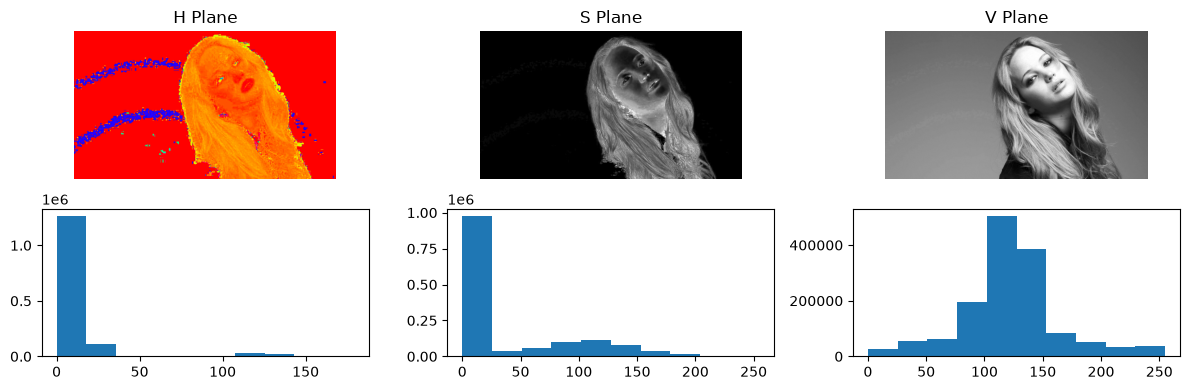

We can use S plane to mask out the background and then equalize the foreground intensities
We can use S plane to mask out the background and then equalize the foreground intensities


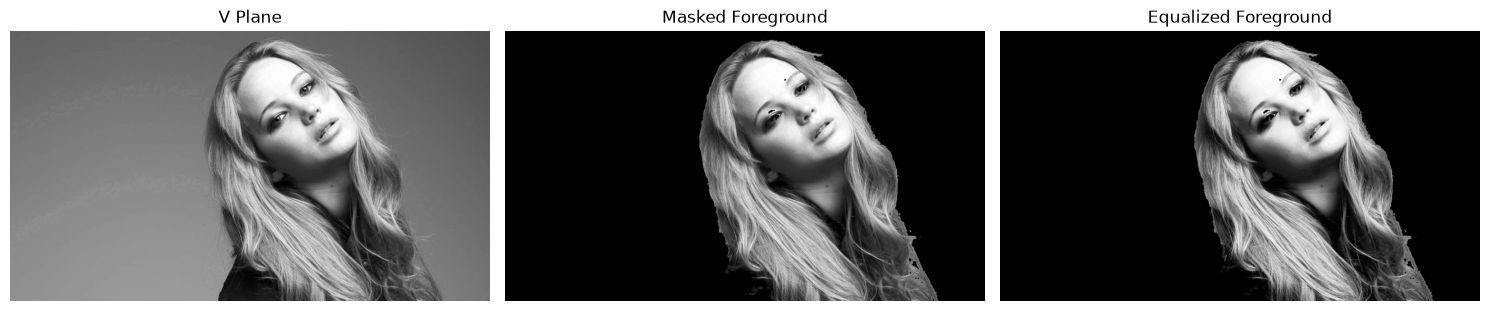

In [ ]:
im6 = cv.imread(os.path.join(IMAGE_DIR, 'WhatsApp Image 2026-09-09 at 20.02.44 (2).jpeg'))
H, S, V = cv.split(cv.cvtColor(im6, cv.COLOR_BGR2HSV))

plt.figure(figsize=(12, 4))
plt.subplot(2, 3, 1)
plt.imshow(H, cmap='hsv')
plt.title('H Plane')
plt.axis('off')
plt.subplot(2, 3, 4)
plt.hist(H.flatten())

plt.subplot(2, 3, 2)
plt.imshow(S, cmap='gray')
plt.title('S Plane')
plt.axis('off')
plt.subplot(2, 3, 5)
plt.hist(S.flatten())

plt.subplot(2, 3, 3)
plt.imshow(V, cmap='gray')
plt.title('V Plane')
plt.axis('off')
plt.subplot(2, 3, 6)
plt.hist(V.flatten())

plt.tight_layout()
plt.show()

print("We can use S plane to mask out the background and then equalize the foreground intensities")
# Use S channel to identify foreground
mask = cv.inRange(S, 15, 255)

# --------------------------------------------------
#  Extract foreground from V channel
# --------------------------------------------------
foreground = cv.bitwise_and(V, V, mask=mask)

# --------------------------------------------------
#  Display intermediate results and final result
# --------------------------------------------------
plt.figure(figsize=(15, 10))

plt.subplot(1, 3, 1)
plt.imshow(V, cmap='gray')
plt.title('V Plane')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(foreground, cmap='gray')
plt.title('Masked Foreground')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(foreground_eq, cmap='gray')
plt.title('Equalized Foreground')
plt.axis('off')

plt.tight_layout()
plt.show()

### Discussion & Observations (Question 6)
*Discuss plane selection choice for segmentation and compare selective foreground equalization vs global equalization...*

--- 
## Question 7: Sobel Filtering & Separable Filtering

### Task Description
Perform Sobel filtering on `q2.jpeg` (Fig. 7 - Einstein image) using three distinct methods:
- **(a)** Using OpenCV `cv.filter2D` with full 2D Sobel kernel.
- **(b)** Manual implementation of 2D convolution for Sobel filtering.
- **(c)** Utilizing kernel separability property:
$$
\begin{bmatrix}
1 & 0 & -1 \\
2 & 0 & -2 \\
1 & 0 & -1
\end{bmatrix} = \begin{bmatrix} 1 \\ 2 \\ 1 \end{bmatrix} * \begin{bmatrix} 1 & 0 & -1 \end{bmatrix}
$$
Perform sequential 1D horizontal and vertical convolutions.

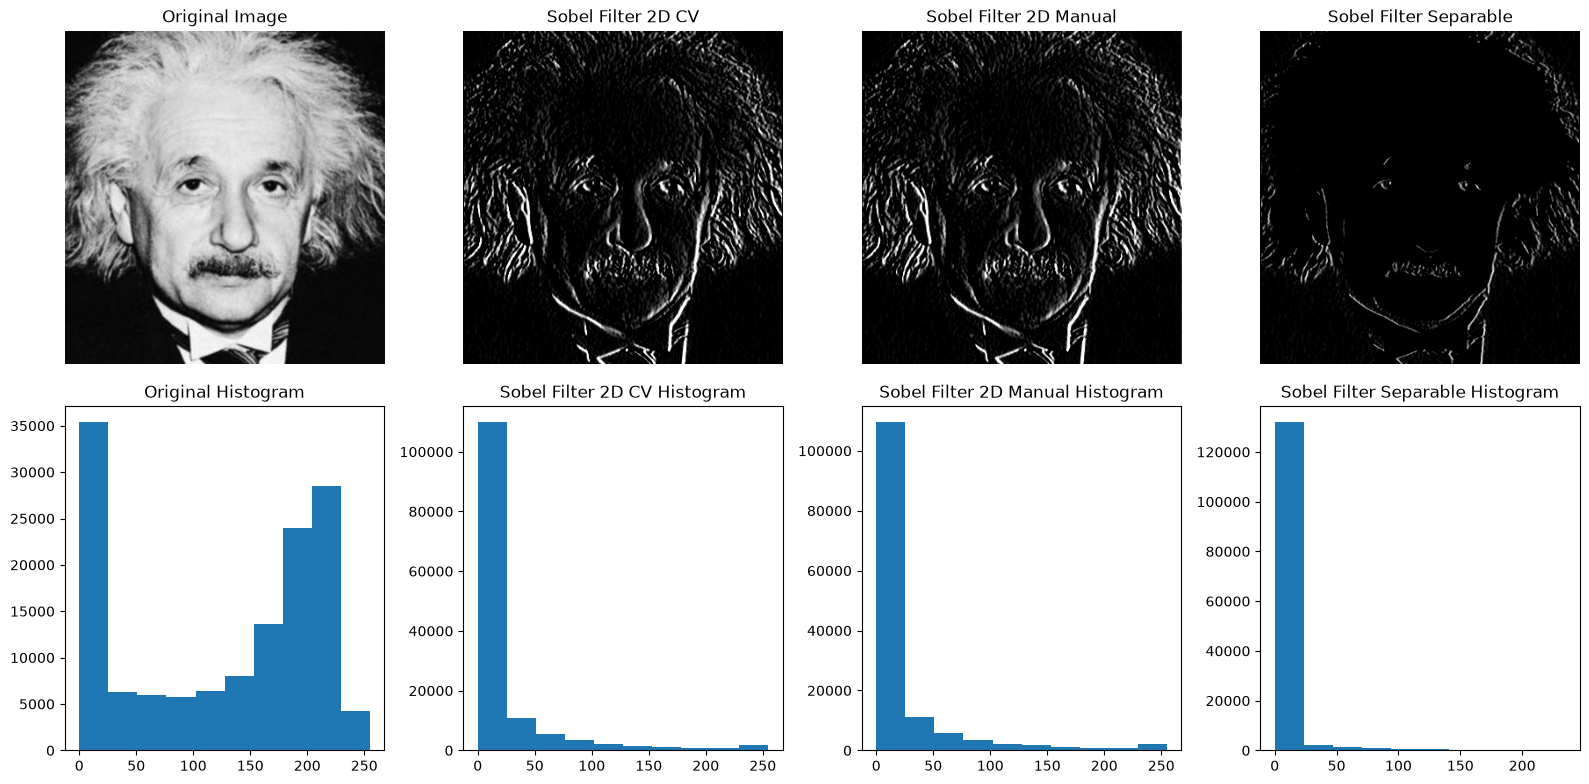

In [42]:
sobel_filter_x = np.array([1, 0, -1])
sobel_filter_y = np.array([1, 2, 1])


def sobel_filter2d_cv(im: np.ndarray) -> np.ndarray:
    """(a) Sobel filtering using cv.filter2D"""

    sobel_filter = np.outer(sobel_filter_y, sobel_filter_x)

    return cv.filter2D(
        im,
        -1,
        sobel_filter
    )


def sobel_filter2d_manual(im: np.ndarray) -> np.ndarray:
    """(b) Sobel filtering using manual 2D convolution loop"""

    # Create 2D Sobel kernel
    kernel = np.outer(sobel_filter_y, sobel_filter_x)

    # Padding size for 3x3 kernel
    pad = kernel.shape[0] // 2

    # Pad image with zeros
    padded = np.pad(
        im,
        ((pad, pad), (pad, pad)),
        mode='constant',
        constant_values=0
    )

    # Output image
    output = np.zeros_like(im, dtype=np.float64)

    # Manual convolution
    for i in range(im.shape[0]):
        for j in range(im.shape[1]):

            # Extract 3x3 neighbourhood
            region = padded[
                i:i + kernel.shape[0],
                j:j + kernel.shape[1]
            ]

            # Convolution
            output[i, j] = np.sum(region * kernel)

    # Clip to valid image range
    output = np.clip(output, 0, 255)

    return output.astype(np.uint8)


def sobel_filter_separable(im: np.ndarray) -> np.ndarray:
    """(c) Sobel filtering using 1D separable kernel decomposition"""

    # First apply vertical smoothing [1, 2, 1]^T
    temp = cv.filter2D(
        im,
        -1,
        sobel_filter_y.reshape(-1, 1)
    )

    # Then apply horizontal derivative [1, 0, -1]
    output = cv.filter2D(
        temp,
        -1,
        sobel_filter_x.reshape(1, -1)
    )

    return output

# --- Template Execution ---
im7 = cv.imread(os.path.join(IMAGE_DIR, 'WhatsApp Image 2026-09-09 at 20.02.43 (2).jpeg'), cv.IMREAD_GRAYSCALE)

fig, ax = plt.subplots(2, 4, figsize=(16, 8))

# --------------------------------------------------
# Images
# --------------------------------------------------

ax[0, 0].imshow(im7, cmap='gray')
ax[0, 0].set_title('Original Image')
ax[0, 0].axis('off')

ax[0, 1].imshow(sobel_filter2d_cv(im7), cmap='gray')
ax[0, 1].set_title('Sobel Filter 2D CV')
ax[0, 1].axis('off')

ax[0, 2].imshow(sobel_filter2d_manual(im7), cmap='gray')
ax[0, 2].set_title('Sobel Filter 2D Manual')
ax[0, 2].axis('off')

ax[0, 3].imshow(sobel_filter_separable(im7), cmap='gray')
ax[0, 3].set_title('Sobel Filter Separable')
ax[0, 3].axis('off')


# --------------------------------------------------
# Histograms
# --------------------------------------------------

ax[1, 0].hist(im7.flatten())
ax[1, 0].set_title('Original Histogram')

ax[1, 1].hist(sobel_filter2d_cv(im7).flatten())
ax[1, 1].set_title('Sobel Filter 2D CV Histogram')

ax[1, 2].hist(sobel_filter2d_manual(im7).flatten())
ax[1, 2].set_title('Sobel Filter 2D Manual Histogram')

ax[1, 3].hist(sobel_filter_separable(im7).flatten())
ax[1, 3].set_title('Sobel Filter Separable Histogram')


plt.tight_layout()
plt.show()

In [43]:
import time

# --------------------------------------------------
# Measure filtering process times
# --------------------------------------------------

start = time.perf_counter()
sobel_cv = sobel_filter2d_cv(im7)
time_cv = time.perf_counter() - start


start = time.perf_counter()
sobel_manual = sobel_filter2d_manual(im7)
time_manual = time.perf_counter() - start


start = time.perf_counter()
sobel_separable = sobel_filter_separable(im7)
time_separable = time.perf_counter() - start


# --------------------------------------------------
# Print processing times
# --------------------------------------------------

print(f"Sobel 2D CV time       : {time_cv:.6f} seconds")
print(f"Sobel 2D Manual time   : {time_manual:.6f} seconds")
print(f"Sobel Separable time   : {time_separable:.6f} seconds")

Sobel 2D CV time       : 0.000546 seconds
Sobel 2D Manual time   : 0.629978 seconds
Sobel Separable time   : 0.000281 seconds


### Discussion & Observations (Question 7)
2D kernel method gives hiher accurate filter but in order of computation 1D kernel is performing better with less inaccuracies

--- 
## Question 8: Image Zooming (Nearest-Neighbor & Bilinear)

### Task Description
Write a custom program/function `zoom_image(im, scale_factor, method)` to resize images by factor $s \in (0, 10]$.

### Requirements:
1. Implement interpolation methods:
   - **(a)** Nearest-neighbor interpolation
   - **(b)** Bilinear interpolation
2. Evaluate algorithm using the provided image pairs (2 large originals & 2 scaled-down versions).
3. Scale up small images by a factor of 4.
4. Compute **Normalized Sum of Squared Differences (SSD)** by comparing upscaled images against original high-resolution targets:
$$\text{SSD}_{\text{norm}} = \frac{\sum_{i,j} (I_{\text{orig}}(i,j) - I_{\text{zoomed}}(i,j))^2}{\sum_{i,j} I_{\text{orig}}(i,j)^2}$$

Image 1 loaded successfully: (270, 480)
Image 2 loaded successfully: (300, 480)
Image 3 loaded successfully: (365, 600)
Image 4 loaded successfully: (28, 50)


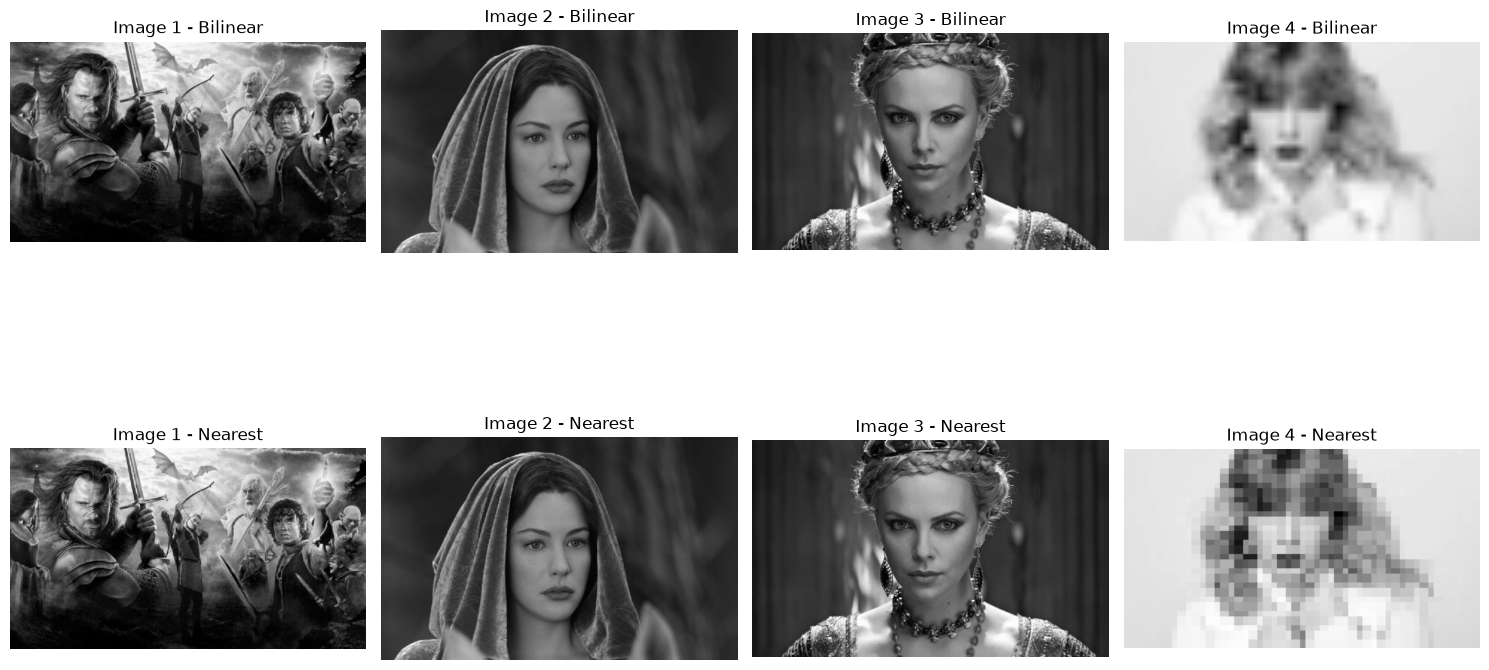


Zoomed image sizes:
Image 1: Original = (270, 480), Zoomed = (1080, 1920)
Image 2: Original = (300, 480), Zoomed = (1200, 1920)
Image 3: Original = (365, 600), Zoomed = (1460, 2400)
Image 4: Original = (28, 50), Zoomed = (112, 200)

Normalized SSD:
----------------------------------------

Image 1
  Nearest  SSD : 88.4732
  Bilinear SSD : 81.0774

Image 2
  Nearest  SSD : 30.0705
  Bilinear SSD : 28.2119

Image 3
  Nearest  SSD : 48.6448
  Bilinear SSD : 44.0588

Image 4
  Nearest  SSD : 112.8279
  Bilinear SSD : 104.4471


In [52]:
# ============================================================
# Zoom image using custom interpolation
# ============================================================

def zoom_image(
    im: np.ndarray,
    factor: float,
    method: str = 'bilinear'
) -> np.ndarray:
    """
    Zooms image by given scale factor using custom interpolation.

    Parameters:
        im (np.ndarray): Input grayscale image
        factor (float): Zoom factor in (0, 10]
        method (str): 'nearest' or 'bilinear'

    Returns:
        np.ndarray: Zoomed image
    """

    if im is None:
        raise ValueError("Input image is None. Check the image path.")

    if factor <= 0 or factor > 10:
        raise ValueError("factor must be in the range (0, 10]")

    if method not in ['nearest', 'bilinear']:
        raise ValueError("method must be 'nearest' or 'bilinear'")

    # --------------------------------------------------------
    # Output image size
    # --------------------------------------------------------

    out_height = int(round(im.shape[0] * factor))
    out_width = int(round(im.shape[1] * factor))

    im_out = np.zeros(
        (out_height, out_width),
        dtype=np.uint8
    )

    # ========================================================
    # Nearest Neighbor Interpolation
    # ========================================================

    if method == 'nearest':

        for i in range(out_height):
            for j in range(out_width):

                # Map output coordinate to input coordinate
                src_i = int(round(i / factor))
                src_j = int(round(j / factor))

                # Prevent going outside image boundaries
                src_i = min(src_i, im.shape[0] - 1)
                src_j = min(src_j, im.shape[1] - 1)

                # Copy nearest pixel
                im_out[i, j] = im[src_i, src_j]

    # ========================================================
    # Bilinear Interpolation
    # ========================================================

    else:

        for i in range(out_height):
            for j in range(out_width):

                # Map output coordinate to input coordinate
                src_i = i / factor
                src_j = j / factor

                # Coordinates of top-left neighboring pixel
                i0 = int(np.floor(src_i))
                j0 = int(np.floor(src_j))

                # Coordinates of bottom-right neighboring pixel
                i1 = min(i0 + 1, im.shape[0] - 1)
                j1 = min(j0 + 1, im.shape[1] - 1)

                # Fractional distances
                di = src_i - i0
                dj = src_j - j0

                # Four neighboring pixels
                p00 = im[i0, j0]
                p01 = im[i0, j1]
                p10 = im[i1, j0]
                p11 = im[i1, j1]

                # Bilinear interpolation
                value = (
                    p00 * (1 - di) * (1 - dj) +
                    p01 * (1 - di) * dj +
                    p10 * di * (1 - dj) +
                    p11 * di * dj
                )

                # Convert to valid grayscale range
                im_out[i, j] = np.clip(
                    round(value),
                    0,
                    255
                )

    return im_out


# ============================================================
# Compute Normalized SSD
# ============================================================

def compute_normalized_ssd(
    im_orig: np.ndarray,
    im_zoomed: np.ndarray
) -> float:
    """
    Computes normalized sum of squared differences.

    The zoomed image is resized back to the original image
    dimensions before calculating the SSD.

    Parameters:
        im_orig (np.ndarray): Original image
        im_zoomed (np.ndarray): Zoomed image

    Returns:
        float: Normalized SSD
    """

    # Resize zoomed image back to original size
    im_resized = cv.resize(
        im_zoomed,
        (im_orig.shape[1], im_orig.shape[0]),
        interpolation=cv.INTER_AREA
    )

    # Convert to floating point
    orig = im_orig.astype(np.float64)
    resized = im_resized.astype(np.float64)

    # Sum of squared differences
    ssd = np.sum(
        (orig - resized) ** 2
    )

    # Normalize by number of pixels
    normalized_ssd = ssd / orig.size

    return normalized_ssd


# ============================================================
# Image Directory
# ============================================================

# Make sure IMAGE_DIR points to the folder containing:
#
# im01small.png
# im02small.png
# im03small.png
# im04small.png
#
# If IMAGE_DIR is already defined in your notebook, you can
# remove the following line.

# IMAGE_DIR = "path/to/your/image/folder"


# ============================================================
# Load Images
# ============================================================

images = []

for i in range(1, 5):

    filename = f"im0{i}small.png"
    path = os.path.join(IMAGE_DIR, filename)

    # Load grayscale image
    im = cv.imread(
        path,
        cv.IMREAD_GRAYSCALE
    )

    # Check whether image was loaded successfully
    if im is None:
        raise FileNotFoundError(
            f"\nCould not load image:\n{path}\n"
            f"\nPlease check that the filename and IMAGE_DIR are correct."
        )

    images.append(im)

    print(
        f"Image {i} loaded successfully: "
        f"{im.shape}"
    )


# ============================================================
# Zoom All Images
# ============================================================

factor = 4.0

bilinear_images = [
    zoom_image(
        im,
        factor,
        method='bilinear'
    )
    for im in images
]

nearest_images = [
    zoom_image(
        im,
        factor,
        method='nearest'
    )
    for im in images
]


# ============================================================
# Display Bilinear and Nearest Images
# ============================================================

fig, ax = plt.subplots(
    2,
    4,
    figsize=(15, 10)
)

for i in range(4):

    # --------------------------------------------------------
    # Bilinear
    # --------------------------------------------------------

    ax[0, i].imshow(
        bilinear_images[i],
        cmap='gray'
    )

    ax[0, i].set_title(
        f'Image {i + 1} - Bilinear'
    )

    ax[0, i].axis('off')


    # --------------------------------------------------------
    # Nearest Neighbor
    # --------------------------------------------------------

    ax[1, i].imshow(
        nearest_images[i],
        cmap='gray'
    )

    ax[1, i].set_title(
        f'Image {i + 1} - Nearest'
    )

    ax[1, i].axis('off')


plt.tight_layout()
plt.show()


# ============================================================
# Print Zoomed Image Sizes
# ============================================================

print("\nZoomed image sizes:")

for i in range(4):

    print(
        f"Image {i + 1}: "
        f"Original = {images[i].shape}, "
        f"Zoomed = {bilinear_images[i].shape}"
    )


# ============================================================
# Calculate Normalized SSD
# ============================================================

print("\nNormalized SSD:")
print("-" * 40)

for i, im in enumerate(images):

    # Nearest-neighbor SSD
    ssd_nearest = compute_normalized_ssd(
        im,
        nearest_images[i]
    )

    # Bilinear SSD
    ssd_bilinear = compute_normalized_ssd(
        im,
        bilinear_images[i]
    )

    print(f"\nImage {i + 1}")

    print(
        f"  Nearest  SSD : "
        f"{ssd_nearest:.4f}"
    )

    print(
        f"  Bilinear SSD : "
        f"{ssd_bilinear:.4f}"
    )

### Discussion & Observations (Question 8)
In all cases the bilateral one gives more soomther output than the nearest one it is so much visible from the last picture. So as a monitor SSD has also proven that.

--- 
## Question 9: GrabCut Segmentation & Background Blurring

### Task Description
Consider the Marguerite Daisy flower image (Fig. 8).
- **(a)** Use `cv.grabCut` to segment flower foreground. Show final segmentation mask, extracted foreground image, and extracted background image.
- **(b)** Produce enhanced image with a substantially blurred background (using Gaussian filter). Display original alongside enhanced image.
- **(c)** **Discussion Question:** Why is the background area just beyond the edge of the flower quite dark in the enhanced image?

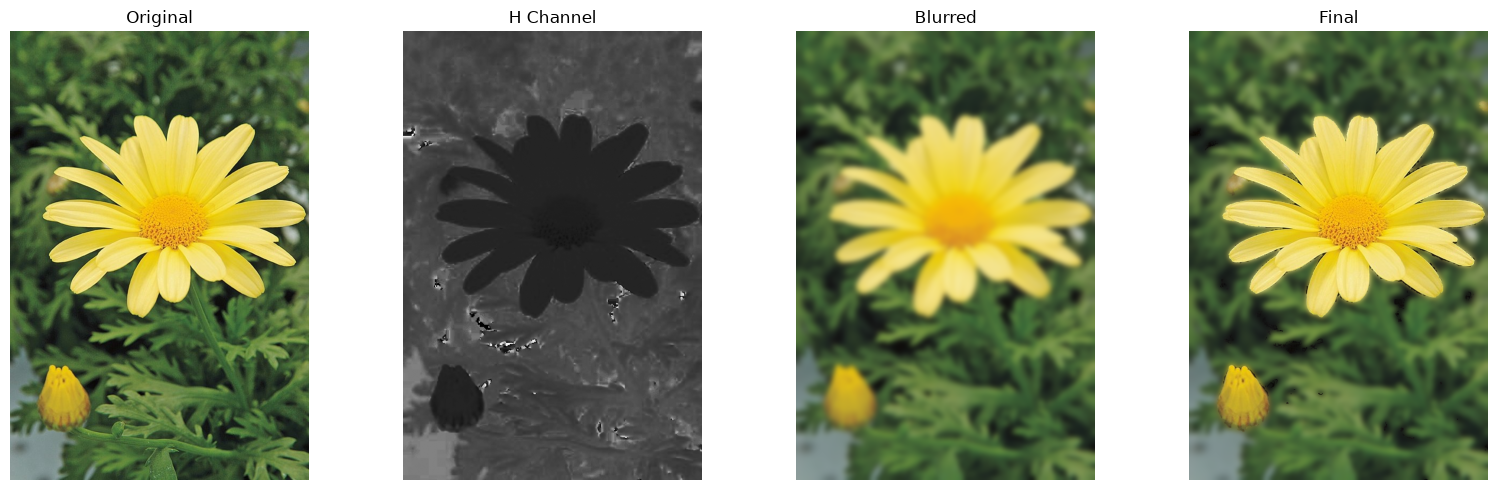

In [63]:
# Convert to HSV
hsv = cv.cvtColor(im9, cv.COLOR_BGR2HSV)

# Get H channel
H, S, V = cv.split(hsv)

# Create mask from H channel
mask = cv.inRange(H, 0, 30)

# Blur the whole image
blurred = cv.GaussianBlur(im9, (31, 31), 0)

# Put original flower on blurred background
final = blurred.copy()
final[mask > 0] = im9[mask > 0]


# Display
fig, ax = plt.subplots(1, 4, figsize=(16, 5))

ax[0].imshow(cv.cvtColor(im9, cv.COLOR_BGR2RGB))
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(H, cmap="gray")
ax[1].set_title("H Channel")
ax[1].axis("off")

ax[2].imshow(cv.cvtColor(blurred, cv.COLOR_BGR2RGB))
ax[2].set_title("Blurred")
ax[2].axis("off")

ax[3].imshow(cv.cvtColor(final, cv.COLOR_BGR2RGB))
ax[3].set_title("Final")
ax[3].axis("off")

plt.tight_layout()
plt.show()

### Discussion & Answer to Part (c)
When we blur background it causes for doreground artifacts to come in so the out put is get artifacts at the edges

--- 
## Question 10: Edge-Preserving Bilateral Filtering

### Task Description
Consider Lake Minaret image (Fig. 9).
- **(a)** Use OpenCV `cv.bilateralFilter` with spatial parameter $\sigma_s$ and range parameter $\sigma_r$. Display original image, Gaussian blurred image (similar spatial kernel), and bilateral filtered image side-by-side.
- **(b)** Implement custom bilateral filter from scratch. Compare results with OpenCV's `cv.bilateralFilter`. Display images side-by-side and evaluate results with a quantitative measure (e.g. MSE, PSNR, or SSIM).

In [ ]:
def custom_bilateral_filter(im: np.ndarray, d: int, sigma_color: float, sigma_space: float) -> np.ndarray:
    """
    Custom implementation of 2D Bilateral Filter.
    
    Parameters:
        im (np.ndarray): Grayscale or color image
        d (int): Diameter of neighborhood domain
        sigma_color (float): Range Gaussian standard deviation
        sigma_space (float): Spatial Gaussian standard deviation
    """
    # TODO: Pre-compute spatial domain Gaussian weights
    # TODO: Iterate over pixels and compute intensity/range weight matrix
    # TODO: Normalize combined kernel weights W_p and compute filtered pixel intensity
    pass

# --- Template Execution ---
im10 = cv.imread(os.path.join(IMAGE_DIR, 'WhatsApp Image 2026-09-09 at 20.02.44 (3).jpg'))
# TODO: Apply cv.bilateralFilter
# TODO: Apply GaussianBlur with comparable kernel size
# TODO: Run custom_bilateral_filter
# TODO: Compute PSNR / SSIM between OpenCV bilateral filter and custom bilateral filter
# TODO: Display original, Gaussian blurred, OpenCV bilateral, and custom bilateral outputs side-by-side

### Discussion & Observations (Question 10)
*Discuss edge preservation behavior, effect of sigma_color vs sigma_space, and quantitative evaluation metrics...*